In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pandas as pd
from src.environment import HotelPricingEnv
from src.baseline_agents import (fixed_price_agent,random_price_agent,discount_agent)

In [3]:
env = HotelPricingEnv()

In [4]:
def evaluate_agent(agent_name,episodes=50):
    revenues = []
    for _ in range(episodes):
        state,_ = env.reset()
        total_reward = 0
        done = False
        while not done:
            if agent_name == "Fixed":
                action = fixed_price_agent()
            elif agent_name == "Random":
                action = random_price_agent()
            else:
                action = discount_agent(env.day)
            state, reward, done, _, info = env.step(action)
            total_reward += reward
        revenues.append(total_reward)
    return sum(revenues) / len(revenues)

In [5]:
fixed = evaluate_agent("Agent")
random = evaluate_agent("Random")
discount = evaluate_agent("Discount")
print("Fixed Agent: ",fixed)
print("Random Agent: ",random)
print("Discount Agent: ",discount)

Fixed Agent:  7360.0
Random Agent:  5433.6
Discount Agent:  7367.2


In [6]:
results = pd.DataFrame({
    "Strategy":["Fixed",
                "Random",
                "Discount"],
    "Average Revenue":[fixed,
                       random,
                       discount]
})
results

,Strategy,Average Revenue
0,Fixed,7360.0
1,Random,5433.6
2,Discount,7367.2


In [7]:
results.to_csv(r"..\data\processed\baselie_results.csv",index=False)
print("Baseline results saved.")

Baseline results saved.


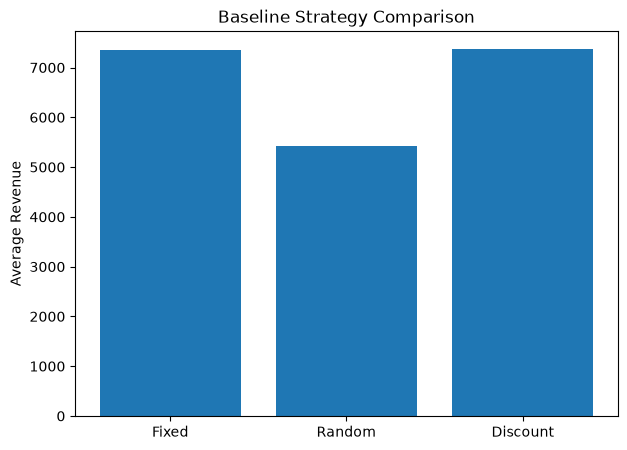

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(results["Strategy"],results["Average Revenue"])

plt.title("Baseline Strategy Comparison")

plt.ylabel("Average Revenue")

plt.show()